# Задание 1 — Аналитика добычи нефти



In [1]:
import os, io, warnings
import boto3
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

PG_URI = (
    f"postgresql+psycopg2://"
    f"{os.getenv('PG_USER','oilfield')}:{os.getenv('PG_PASSWORD','oilfield123')}"
    f"@{os.getenv('PG_HOST','postgres')}:{os.getenv('PG_PORT','5432')}"
    f"/{os.getenv('PG_DB','oilfield')}"
)
MINIO_ENDPOINT   = os.getenv('MINIO_ENDPOINT',   'http://minio:9000')
MINIO_ACCESS_KEY = os.getenv('MINIO_ACCESS_KEY', 'minioadmin')
MINIO_SECRET_KEY = os.getenv('MINIO_SECRET_KEY', 'minioadmin123')
BUCKET           = os.getenv('MINIO_BUCKET',     'oilfield')

engine = create_engine(PG_URI)

s3 = boto3.client(
    's3',
    endpoint_url=MINIO_ENDPOINT,
    aws_access_key_id=MINIO_ACCESS_KEY,
    aws_secret_access_key=MINIO_SECRET_KEY,
)

def read_parquet(bucket, prefix):
    resp = s3.list_objects_v2(Bucket=bucket, Prefix=prefix)
    frames = []
    for obj in resp.get('Contents', []):
        if obj['Key'].endswith('.parquet'):
            buf = io.BytesIO()
            s3.download_fileobj(bucket, obj['Key'], buf)
            buf.seek(0)
            frames.append(pq.read_table(buf).to_pandas())
    return pd.concat(frames, ignore_index=True)

## 1. Загрузка данных

In [2]:
wells_df = read_parquet(BUCKET, 'wells/wells.parquet')
prod_df  = read_parquet(BUCKET, 'production/production.parquet')
tele_df  = read_parquet(BUCKET, 'well_telemetry/well_telemetry.parquet')

prod_df['date'] = pd.to_datetime(prod_df['date'])
print(f'wells:          {wells_df.shape}')
print(f'production:     {prod_df.shape}')
print(f'well_telemetry: {tele_df.shape}')

wells:          (5, 7)
production:     (150, 10)
well_telemetry: (48, 10)


## 2. EDA — исследовательский анализ данных

In [3]:
df = prod_df.merge(wells_df[['well_id', 'name', 'field_name', 'region', 'status']], on='well_id')
print(df.shape)
display(df.head(3))

(150, 14)


,prod_id,well_id,date,oil_ton,gas_m3,water_m3,energy_kwh,downtime_hours,temperature,pressure,name,field_name,region,status
0,1,1,2025-10-01,212.4,55200.0,182.3,7450.0,0.5,88.1,120.4,Well-101,Severo-Ural,Khanty-Mansi,active
1,2,1,2025-10-02,213.8,55320.0,181.9,7490.0,0.3,87.8,121.0,Well-101,Severo-Ural,Khanty-Mansi,active
2,3,1,2025-10-03,211.9,55040.0,183.2,7430.0,0.7,88.5,119.8,Well-101,Severo-Ural,Khanty-Mansi,active


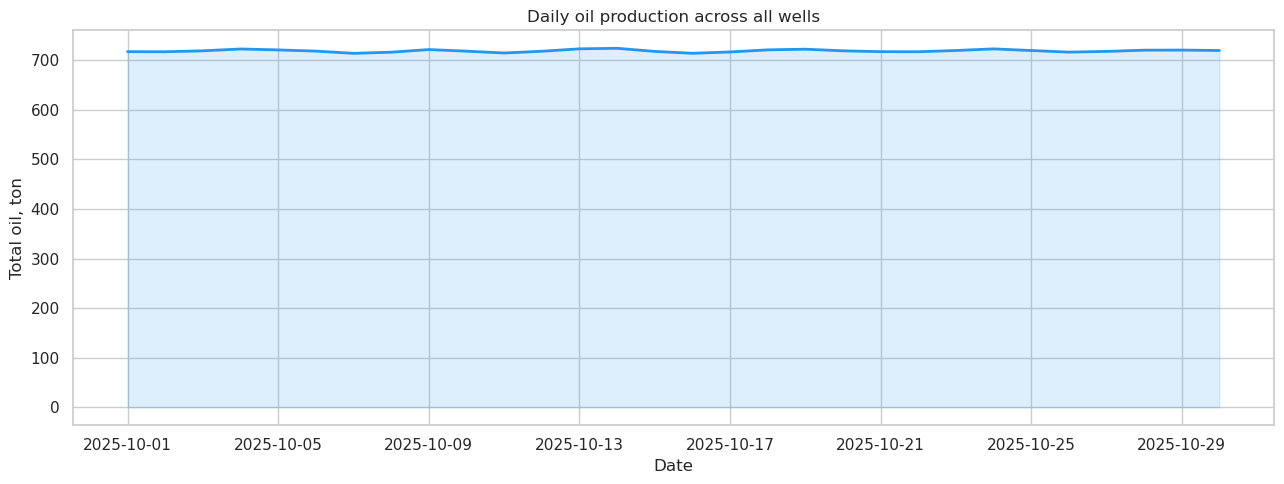

In [4]:
daily = df.groupby('date').agg(total_oil_ton=('oil_ton', 'sum')).reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily['date'], daily['total_oil_ton'], color='#2196F3', linewidth=2)
ax.fill_between(daily['date'], daily['total_oil_ton'], alpha=0.15, color='#2196F3')
ax.set_xlabel('Date')
ax.set_ylabel('Total oil, ton')
ax.set_title('Daily oil production across all wells')
plt.tight_layout()
plt.show()

## 3. График 1 — Суточная добыча нефти

## 4. KPI по скважинам

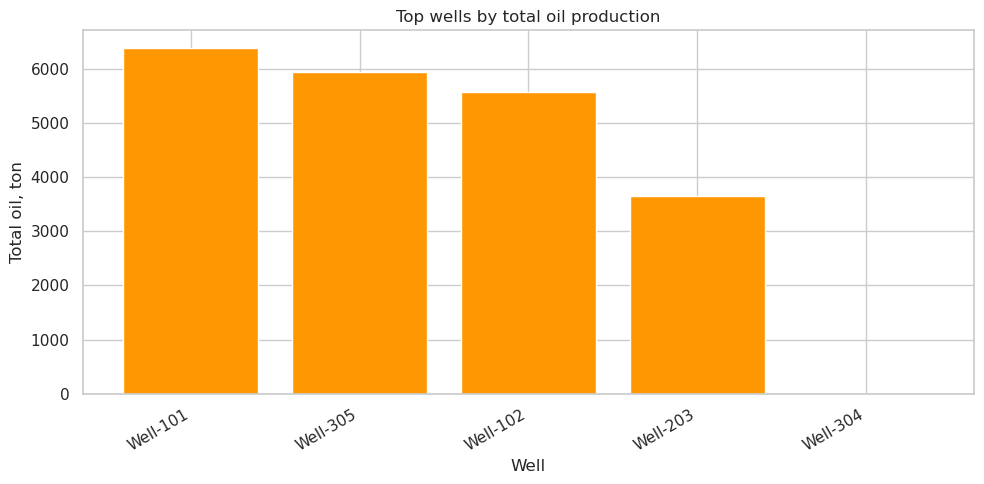

In [5]:
well_totals = df.groupby('name').agg(total_oil_ton=('oil_ton', 'sum')).reset_index().sort_values('total_oil_ton', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(well_totals['name'], well_totals['total_oil_ton'], color='#FF9800')
ax.set_xlabel('Well')
ax.set_ylabel('Total oil, ton')
ax.set_title('Top wells by total oil production')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 5. График 2 — Топ скважин по добыче

## 6. График 3 — Heatmap: давление vs дебит

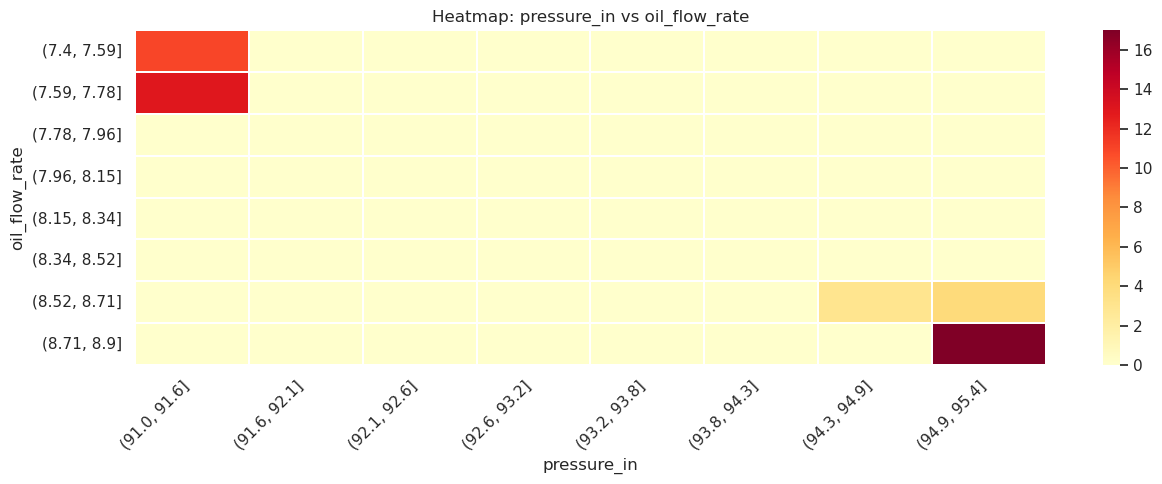

In [6]:
tele_clean = tele_df.dropna(subset=['pressure_in', 'oil_flow_rate'])
tele_clean['p_bin']    = pd.cut(tele_clean['pressure_in'],    bins=8, precision=1)
tele_clean['flow_bin'] = pd.cut(tele_clean['oil_flow_rate'], bins=8, precision=2)

hm = tele_clean.pivot_table(values='record_id', index='flow_bin', columns='p_bin', aggfunc='count', fill_value=0)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(hm, cmap='YlOrRd', linewidths=0.3, ax=ax)
ax.set_title('Heatmap: pressure_in vs oil_flow_rate')
ax.set_xlabel('pressure_in')
ax.set_ylabel('oil_flow_rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Лучшие и худшие скважины

In [7]:
kpi = (
    df.groupby(['well_id', 'name', 'field_name'])
    .agg(avg_oil_ton=('oil_ton', 'mean'), total_downtime=('downtime_hours', 'sum'))
    .reset_index()
)
display(kpi)

,well_id,name,field_name,avg_oil_ton,total_downtime
0,1,Well-101,Severo-Ural,213.150000,14.5
1,2,Well-102,Severo-Ural,185.816667,21.8
2,3,Well-203,Vostok-Field,121.696667,58.4
3,4,Well-304,Zapad-Field,0.000000,720.0
4,5,Well-305,Zapad-Field,198.430000,13.1


## 8. Сохранение витрины в PostgreSQL

In [8]:
kpi.to_sql('analytics_well_kpi', engine, if_exists='replace', index=False)
print(f'Saved {len(kpi)} rows to analytics_well_kpi')

Saved 5 rows to analytics_well_kpi
